# **Comparación de Modelos Alternativos**

## **Introducción**

Luego de identificar que el modelo **XGBoost clásico** ofrecía el mejor rendimiento en el enfoque multiclase, el siguiente paso fue intentar **superarlo en desempeño predictivo (F1 macro)** o **mejorar su eficiencia computacional (CPU Time)**. Esta búsqueda derivó en un proceso experimental riguroso en el que se exploraron múltiples algoritmos de clasificación, distintas estrategias de balanceo de clases y técnicas de optimización hiperparamétrica.

Durante estas pruebas se aplicaron técnicas como **SMOTE, SMOTE-NC, ADASYN y SWIM** para mitigar el desbalance de clases. Además, se emplearon métodos avanzados de ajuste de hiperparámetros como **GridSearchCV, RandomizedSearchCV y Optuna**. Este proceso no solo confirmó la solidez del modelo XGBoost, sino que también permitió descubrir que una combinación **Stacking de XGBoost + LightGBM**, originalmente explorada como una alternativa más, ofrecía un balance notable entre desempeño y eficiencia.

A continuación, se presentan por separado los modelos evaluados en el enfoque binario (2 clases) y los aplicados a la clasificación multiclase (3 clases).

---

## **Modelos Evaluados – Clasificación Binaria (2 clases)**

| Modelo                                | F1 Macro | AUC    | CPU Time (s) |
|---------------------------------------|----------|--------|--------------|
| XGBoost (binario)                     | 0.6792   | 0.8143 | 46.63        |
| Stacking (XGBoost + LightGBM)         | 0.6659   | 0.7764 | 1.93         |
| Random Forest (binario)               | 0.6663   | 0.7872 | 193.99       |
| HistGradientBoosting (binario)        | 0.6647   | 0.8014 | 73.24        |
| XGBoost + ExtraTree                   | 0.6370   | 0.7419 | 2.22         |
| SMOTE + AdaBoost (RandomizedSearchCV) | 0.5858   | 0.6973 | 29.92        |
| Balanced Random Forest                | 0.5850   | 0.7515 | 45.16        |
| XGBoost (SWIM)                        | 0.6581   | 0.8277 | 40.80        |
| Extra Tree                            | 0.5810   | 0.6745 | 83.74        |
| Extreme Machine Learning + SMOTE      | 0.5749   | N/D    | 9.58         |







In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

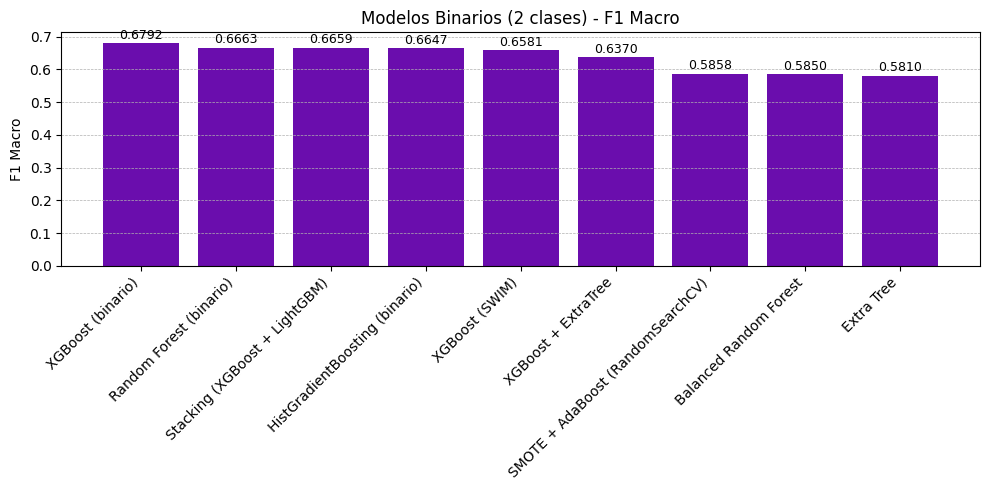

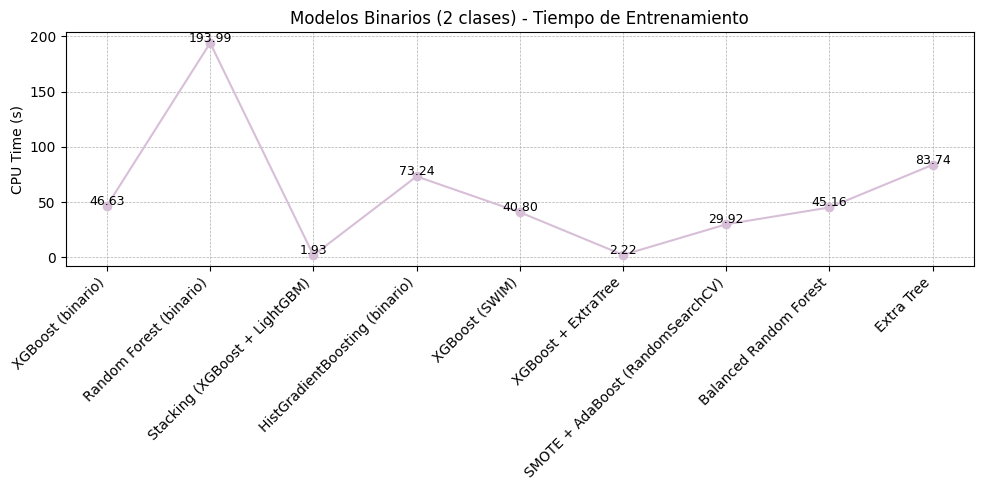

In [ ]:
# Modelos Binarios (2 clases)
data_binario = [
    {"Modelo": "XGBoost (binario)", "F1 Macro": 0.6792, "AUC": 0.8143, "CPU Time (s)": 46.63},
    {"Modelo": "Stacking (XGBoost + LightGBM)", "F1 Macro": 0.6659, "AUC": 0.7764, "CPU Time (s)": 1.93},
    {"Modelo": "Random Forest (binario)", "F1 Macro": 0.6663, "AUC": 0.7872, "CPU Time (s)": 193.99},
    {"Modelo": "HistGradientBoosting (binario)", "F1 Macro": 0.6647, "AUC": 0.8014, "CPU Time (s)": 73.24},
    {"Modelo": "XGBoost + ExtraTree", "F1 Macro": 0.6370, "AUC": 0.7419, "CPU Time (s)": 2.22},
    {"Modelo": "XGBoost (SWIM)", "F1 Macro": 0.6581, "AUC": 0.8277, "CPU Time (s)": 40.80},
    {"Modelo": "SMOTE + AdaBoost (RandomSearchCV)", "F1 Macro": 0.5858, "AUC": 0.6973, "CPU Time (s)": 29.92},
    {"Modelo": "Balanced Random Forest", "F1 Macro": 0.5850, "AUC": 0.7515, "CPU Time (s)": 45.16},
    {"Modelo": "Extra Tree", "F1 Macro": 0.5810, "AUC": 0.6745, "CPU Time (s)": 83.74},
    {"Modelo": "Extreme Machine Learning + SMOTE", "F1 Macro": 0.5749, "AUC": None, "CPU Time (s)": 9.58}
]

df_binario = pd.DataFrame(data_binario)

# F1 Macro (binario)
sorted_binario = df_binario.dropna().sort_values(by="F1 Macro", ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(sorted_binario['Modelo'], sorted_binario['F1 Macro'], color='#6A0DAD')
plt.ylabel("F1 Macro")
plt.title("Modelos Binarios (2 clases) - F1 Macro")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# CPU Time (binario)
plt.figure(figsize=(10, 5))
plt.plot(sorted_binario['Modelo'], sorted_binario['CPU Time (s)'], marker='o', linestyle='-', color='#D8BFD8')
plt.ylabel("CPU Time (s)")
plt.title("Modelos Binarios (2 clases) - Tiempo de Entrenamiento")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', linewidth=0.5)
for i, val in enumerate(sorted_binario['CPU Time (s)']):
    plt.text(i, val + 1, f"{val:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## **Análisis de los Modelos Binarios**

- **XGBoost (binario):** Fue el punto de partida del enfoque binario. Obtuvo la **mejor F1 macro (0.6792)**, con un AUC alto (0.8143), pero su tiempo de entrenamiento fue considerable (46.63 s).

- **Stacking (XGBoost + LightGBM):** Descubierto durante la etapa experimental, este modelo alcanzó un F1 macro competitivo (0.6659) y un tiempo excepcionalmente bajo (1.93 s), convirtiéndose en la **solución más equilibrada entre rendimiento y eficiencia**.

- **Random Forest y HistGradientBoosting:** Ambos modelos se aproximaron a los resultados de XGBoost, con F1 macro por encima de 0.66, pero con tiempos de entrenamiento muy elevados, por lo que fueron descartados para uso práctico.

- **XGBoost + ExtraTree:** Esta combinación intentó complementar las capacidades del boosting con mayor diversidad. Ofreció un F1 macro de 0.6370 con buena eficiencia (2.22 s).

- **XGBoost con SWIM:** Utilizando una estrategia de balanceo novedosa, este modelo logró un AUC superior (0.8277), pero su F1 macro fue ligeramente inferior (0.6581) y el tiempo de ejecución, elevado.

- **Modelos con AdaBoost, Random Forest balanceado y Extreme Machine Learning:** Aunque ofrecieron tiempos moderados, sus F1 macro fueron considerablemente más bajos (rango: 0.5749–0.5858), y por tanto fueron descartados.


## **Modelos Evaluados – Clasificación Multiclase (3 clases)**

| Modelo                     | F1 Macro | AUC    | CPU Time (s) |
|----------------------------|----------|--------|--------------|
| XGBoost clásico            | 0.6700   | 0.7100 | 58.40        |
| HistGradientBoosting       | 0.4474   | 0.7505 | 296.07       |
| EasyEnsembleClassifier     | 0.3688   | 0.6849 | 597.09       |
| BalancedBaggingClassifier  | 0.3679   | 0.4753 | 0.36         |
| ImAdaBoost                 | 0.5372   | N/D    | N/D          |

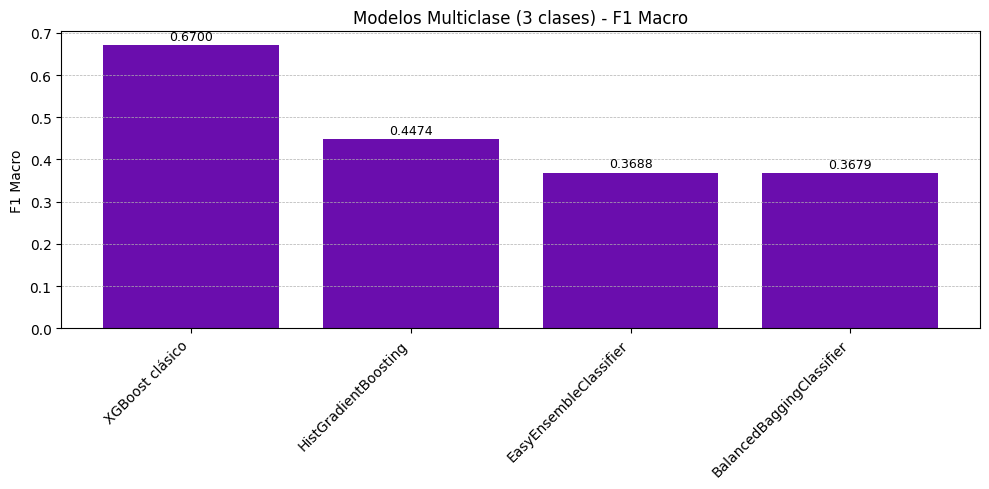

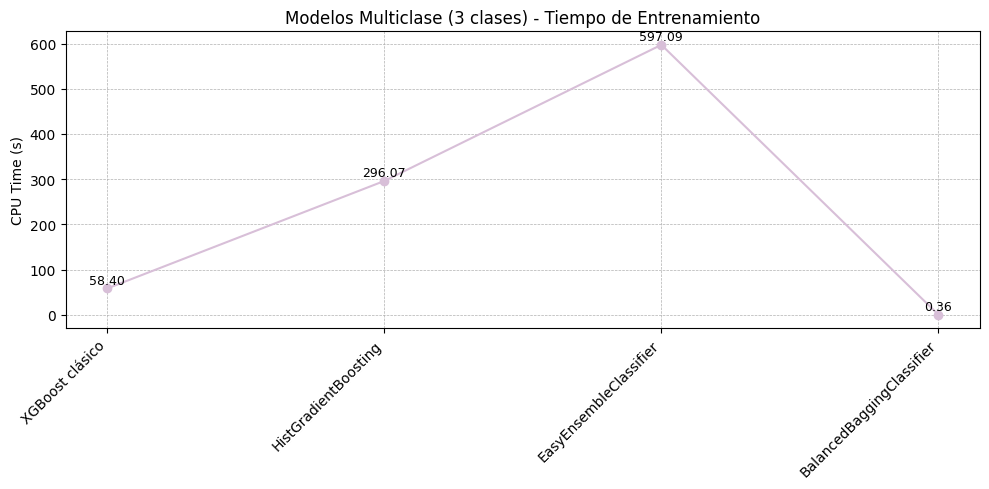

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Modelos Multiclase (3 clases)
data_multiclase = [
    {"Modelo": "XGBoost clásico", "F1 Macro": 0.6700, "AUC": 0.7100, "CPU Time (s)": 58.40},
    {"Modelo": "HistGradientBoosting", "F1 Macro": 0.4474, "AUC": 0.7505, "CPU Time (s)": 296.07},
    {"Modelo": "EasyEnsembleClassifier", "F1 Macro": 0.3688, "AUC": 0.6849, "CPU Time (s)": 597.09},
    {"Modelo": "BalancedBaggingClassifier", "F1 Macro": 0.3679, "AUC": 0.4753, "CPU Time (s)": 0.36},
    {"Modelo": "ImAdaBoost", "F1 Macro": 0.5372, "AUC": None, "CPU Time (s)": None}
]

df_multiclase = pd.DataFrame(data_multiclase)

# F1 Macro (multiclase)
sorted_multi_f1 = df_multiclase.dropna().sort_values(by="F1 Macro", ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(sorted_multi_f1['Modelo'], sorted_multi_f1['F1 Macro'], color='#6A0DAD')
plt.ylabel("F1 Macro")
plt.title("Modelos Multiclase (3 clases) - F1 Macro")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# CPU Time (multiclase)
sorted_multi_time = df_multiclase.dropna().sort_values(by="F1 Macro", ascending=False)
plt.figure(figsize=(10, 5))
plt.plot(sorted_multi_time['Modelo'], sorted_multi_time['CPU Time (s)'], marker='o', linestyle='-', color='#D8BFD8')
plt.ylabel("CPU Time (s)")
plt.title("Modelos Multiclase (3 clases) - Tiempo de Entrenamiento")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', linewidth=0.5)
for i, val in enumerate(sorted_multi_time['CPU Time (s)']):
    plt.text(i, val + 10, f"{val:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()



## **Análisis de los Modelos Multiclase**

- **XGBoost clásico:** Se posicionó como el mejor modelo en el enfoque multiclase, con un F1 macro de 0.67 y AUC de 0.71. Fue el punto de comparación para todo el proyecto.

- **HistGradientBoosting:** A pesar de tener un AUC alto (0.7505), su F1 macro fue bajo (0.4474) y su tiempo de entrenamiento excesivo.

- **EasyEnsemble y BalancedBaggingClassifier:** Mostraron bajo desempeño en F1 macro, especialmente BalancedBagging, que además tuvo un AUC muy bajo. Fueron descartados para este problema.

- **ImAdaBoost:** A pesar de su enfoque adaptativo, su F1 macro (0.5372) y ausencia de métricas complementarias lo dejan por debajo de XGBoost.


## **Conclusión**

El proceso comparativo permitió confirmar que, aunque el modelo **XGBoost clásico binario** es fuerte en precisión, su costo computacional lo hace menos práctico. El modelo **Stacking (XGBoost + LightGBM)** emerge como la **mejor opción global**, con una F1 macro cercana al máximo alcanzado y un tiempo de entrenamiento extremadamente bajo.

Los modelos multiclase, en cambio, mostraron **rendimientos generales inferiores**, reforzando la decisión de reformular el problema como binario. Modelos como EasyEnsemble y BalancedBagging mostraron escaso valor agregado para este tipo de datos.

En conjunto, esta etapa permitió validar rigurosamente las decisiones de modelado y dejó establecida una solución sólida y reproducible para la predicción de desenlaces graves en víctimas de violencia basada en género.
